# 03 · Your first simulation

We'll take a **y-branch** — a 1×2 power splitter — from a GDS layout all the
way to S-parameters and a field profile, running on **beamz**: a free,
open-source (Apache-2.0) FDTD engine on your own CPU. No cloud, no license.

Every simulation in gds_fdtd has the same shape:

> **a `Component` + a `Technology` + a `SimulationSpec`  →  one `SMatrix`.**

Everything before `run()` — loading geometry, solving the waveguide mode,
meshing, estimating cost — is **offline and free**. By the end you'll have
produced, from scratch: the material stack, the guided mode you're launching,
the meshed permittivity, the scattering matrix, and the field splitting one
input into two.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from gds_fdtd.grid import resolve_index
from gds_fdtd.modes import waveguide_mode
from gds_fdtd.plotting import (
    plot_component,
    plot_mode,
    plot_permittivity,
    plot_smatrix,
    plot_tech_stack,
)
from gds_fdtd.smatrix import SMatrix
from gds_fdtd.solvers import get_solver
from gds_fdtd.spec import SimulationSpec
from gds_fdtd.technology import Technology


def _find(rel: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(rel)


HERE = _find("examples/03_first_simulation")
tech = Technology.from_yaml(_find("examples/tech.yaml"))

## 1 · The device

The canonical SiEPIC EBeam `ebeam_y_1550` y-branch, loaded from the
KLayout/SiEPIC PDK. One input (`opt1`, facing −x) splits into two outputs
(`opt2`, `opt3`, facing +x). `from_tech` reads the polygons on each technology
layer and **auto-detects the ports** — you never place them by hand.

SiEPIC-EBeam-PDK Python module: siepic_ebeam_pdk, KLayout technology: EBeam
KLayout SiEPIC-Tools version 0.5.31
SiEPIC-Tools is up to date (0.5.31 vs 0.5.31).
Version check, time: 0.18035531044006348 seconds
SiEPIC-EBeam-PDK Python module: pymacros, v0.4.53


Libraries associated with Technology EBeam: ['EBeam', 'EBeam-ANT', 'EBeam-Dream', 'EBeam-SiN', 'EBeam_Beta']


17:07:16 PDT WARNING: Using canonical configuration directory at                
             '/home/mustafa/.config/tidy3d'. Found legacy directory at          
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

  opt1: at (-7.40, 0.00) µm, 0.500 µm wide, 180°
  opt2: at (7.40, 2.75) µm, 0.500 µm wide, 0°
  opt3: at (7.40, -2.75) µm, 0.500 µm wide, 0°


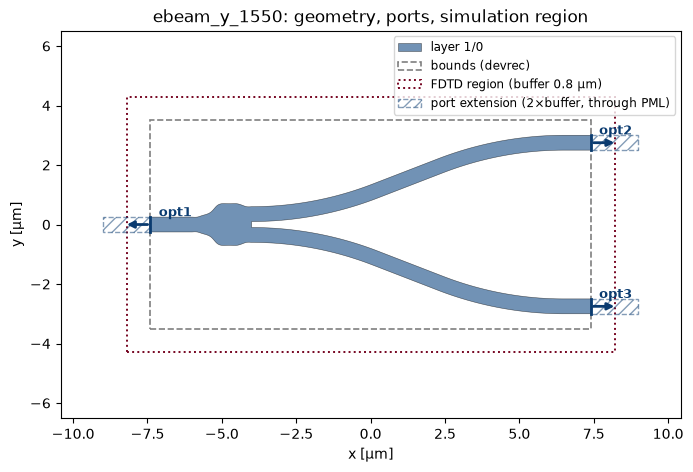

In [2]:
import os  # noqa: E402

import siepic_ebeam_pdk as pdk  # noqa: E402

from gds_fdtd.lyprocessor import load_cell  # noqa: E402
from gds_fdtd.simprocessor import load_component_from_tech  # noqa: E402

gds = os.path.join(os.path.dirname(pdk.__file__), "gds", "EBeam", "ebeam_y_1550.gds")
cell, _layout = load_cell(gds, top_cell="ebeam_y_1550")
component = load_component_from_tech(cell=cell, tech=tech)
component.name = "ebeam_y_1550"

for p in component.ports:
    print(f"  {p.name}: at ({p.center[0]:.2f}, {p.center[1]:.2f}) µm, {p.width:.3f} µm wide, {p.direction}°")

plot_component(component, spec=SimulationSpec(buffer=0.8))
plt.show()

## 2 · The material stack

The vertical make-up of the chip: a silicon (n ≈ 3.48) waveguide core on an
oxide substrate, clad in more oxide (n ≈ 1.44). This one technology file feeds
every engine.

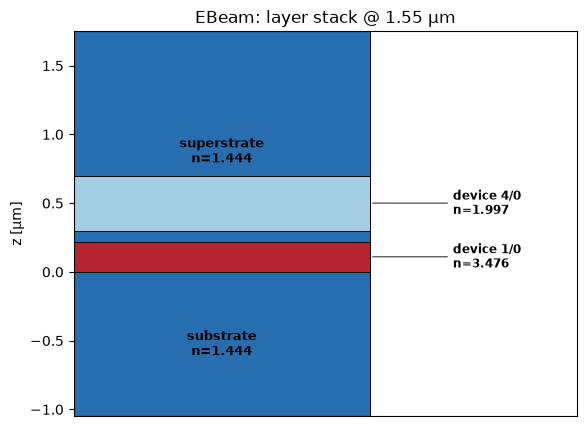

In [3]:
plot_tech_stack(tech, wavelength_um=1.55)
plt.show()

## 3 · The mode we're launching

Before any light propagates, what *guided mode* does the input waveguide
carry? We solve it locally (tidy3d's offline mode solver — no cloud) for the
strip's actual width and thickness. Its **effective index** `n_eff` is the
single number that says how the mode travels; the profile shows the light
hugging the high-index core.

17:07:17 PDT WARNING: Use the remote mode solver with subpixel averaging for    
             better accuracy through 'tidy3d.web.run(...)' or the deprecated    
             'tidy3d.plugins.mode.web.run(...)'. Alternatively, you can install 
             the package 'tidy3d-extras' using 'pip install "tidy3d"' and set   
             'config.simulation.use_local_subpixel=True'.                       

             WARNING: Permittivity spatial data array does not fully cover the  
             requested region.                                                  

input strip 0.500×0.220 µm — TE0 n_eff = 2.4441


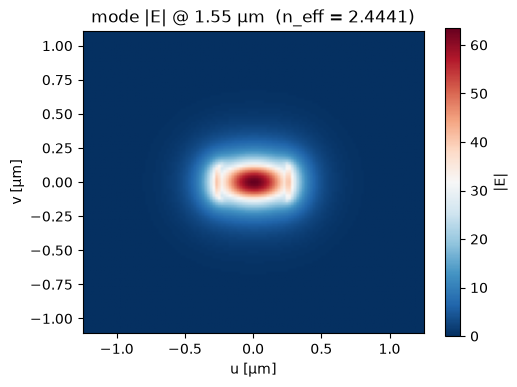

In [4]:
n_core = resolve_index(tech.device[0].material, 1.55).real
n_clad = resolve_index(tech.superstrate.material, 1.55).real
width = component.ports[0].width  # the input strip width
height = tech.device[0].z_span  # core thickness

mode = waveguide_mode(width, height, n_core, n_clad, 1.55)[0]
print(f"input strip {width:.3f}×{height:.3f} µm — TE0 n_eff = {mode.n_eff.real:.4f}")
plot_mode(mode)
plt.show()

## 4 · What the solver meshes

The permittivity grid the FDTD run is built on — the single most useful sanity
check in FDTD: *is my structure what I think it is?* Here, top-down through the
device layer, you can see the input taper fan out into the two branches.

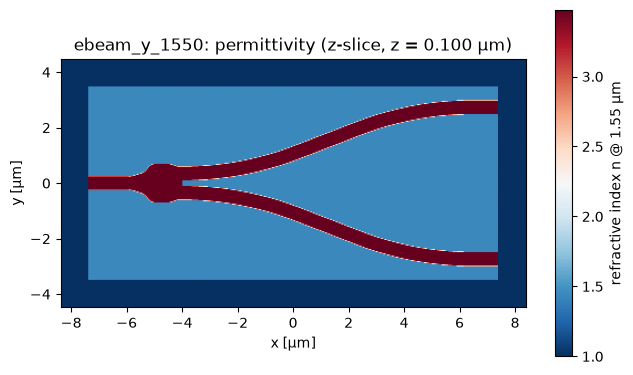

In [5]:
plot_permittivity(component, dx=0.04, axis="z")
plt.show()

## 5 · A free preview

`validate()` lists any problems (empty = good). `build()` constructs the full
scene **offline**; `estimate()` reports the grid size and cost *before you
spend anything*. We keep the job small (mesh 6, five wavelengths) so it fits a
modest laptop.

In [6]:
spec = SimulationSpec(
    wavelength_start=1.5, wavelength_end=1.6, wavelength_points=5, mesh=6,
    z_min=-1.0, z_max=1.11, buffer=0.8,
)
solver = get_solver("beamz")(component, technology=tech, spec=spec)
print("validate():", solver.validate() or "OK — no problems")
print("build():   ", solver.build().summary)
print("estimate():", solver.estimate())

validate(): OK — no problems


● Done: Raster cache hit (3d): dca6d737c3723a585c9eb01d32dd50db74e0714717c236888fc1201314872189.npz | load=0.28s
build():    {'n_ports': 3, 'grid_shape': (70, 161, 279), 'dx_nm': 74.31914077483697, 'n_core': 3.476, 'n_clad': 1.444, 'n_simulations': 3}
estimate(): ResourceEstimate(grid_cells=3144330, memory_gb=0.15092784, n_simulations=3, cost_hint='free local compute (JAX; CPU works, GPU if available)')


## 6 · Run

`run()` is the one call that consumes a resource — on beamz, local CPU time
(a few minutes) at zero cost. It returns the canonical `SMatrix`. We ran it
once and saved the result, so this notebook re-executes instantly:

```python
smatrix = solver.run_cached(".gds_fdtd_cache")   # repeats are free
```

In [7]:
smatrix = SMatrix.from_npz(str(_find("examples/07_choosing_an_engine/recorded/ybranch_beamz.npz")))

# a y-branch's figure of merit is its input split: opt1 into each arm
s21 = float(np.mean(smatrix.magnitude_db(out=2, in_=1)))
s31 = float(np.mean(smatrix.magnitude_db(out=3, in_=1)))
print(f"input split — opt2←opt1: {s21:.2f} dB   opt3←opt1: {s31:.2f} dB")
print("(an ideal lossless 1×2 splitter gives −3.01 dB into each arm)")

input split — opt2←opt1: -3.21 dB   opt3←opt1: -3.29 dB
(an ideal lossless 1×2 splitter gives −3.01 dB into each arm)


There it is — power from `opt1` divides roughly in half into the two arms,
within a few tenths of a dB of the −3 dB ideal. The plot shows how that split
holds across the wavelength band.

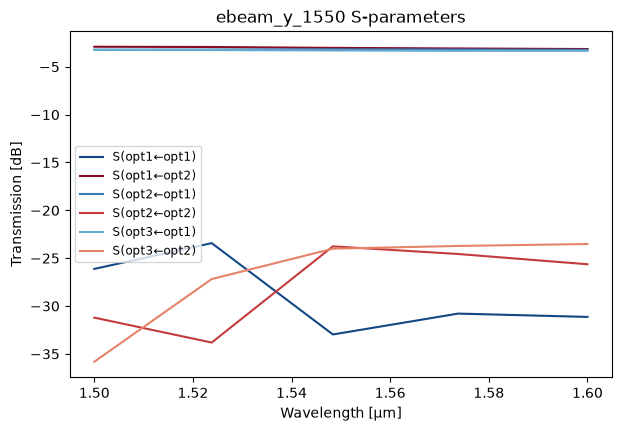

In [8]:
plot_smatrix(smatrix, kind="db")
plt.show()

## 7 · The field

Finally, the |E|² intensity in the device plane for the `opt1` excitation —
the picture worth a thousand S-parameters. Watch the mode launched into the
single input waveguide taper out and split evenly down the two branches.

*(This field was rendered from a small **tidy3d cloud** run of the same
y-branch — the compute is remote, so a full 3-D field costs no local memory.
Every engine can produce this; `07_choosing_an_engine` compares all three.)*

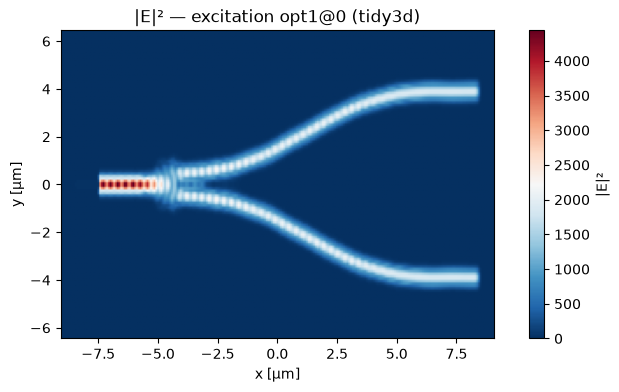

In [9]:
fld = np.load(HERE / "recorded" / "ybranch_tidy3d_field.npz")
mag2 = fld["mag2"]  # (nx, ny) |E|² at band center, opt1 excitation
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(
    mag2.T, origin="lower", cmap="RdBu_r", aspect="equal",
    extent=(float(fld["x0"]), float(fld["x1"]), float(fld["y0"]), float(fld["y1"])),
)
fig.colorbar(im, ax=ax, label="|E|²")
ax.set_xlabel("x [µm]")
ax.set_ylabel("y [µm]")
ax.set_title(f"|E|² — excitation {str(fld['source'])} (tidy3d)")
plt.show()

## Recap & where to go next

From a GDS file you produced a full FDTD result — geometry, the launched mode,
the mesh, a scattering matrix, and the field — with one free engine and no
hand-tuning. The same five lines drive tidy3d and Lumerical too.

- **`04_reading_results`** — everything an `SMatrix` can tell you (loss,
  crosstalk, phase, reciprocity/passivity, and I/O to Touchstone/HDF5).
- **`05_fields_and_modes`** — higher-order modes, dispersion of `n_eff`, and
  richer field views.
- **`07_choosing_an_engine`** — this very y-branch on beamz, tidy3d, and
  Lumerical, and how closely they agree.